<h1 style="color: #06402B ;">Using EasyOCR on The Spiritualist Newspaper (1869 - 1882)</h1>

<p align="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTx7kQCmpJvs1rHt1zDwU37f_A5AZSBZ1IYoA&s" width="500" alt="EasyOCR Logo">
</p>

This notebook was created in November 2025 for the National Library of Scotland (NLS) by Dr Joe Nockels, Digital Fellow. His related project, 'Recognising Text, Recognising Processes: eXplainable Automatic Text Recognition for Scottish Spiritualist Newspapers', was made possible through support from the NLS and Digital Humanities Institute (DHI), University of Sheffield. Images used of *The Spiritualist Newspaper* were first captured by the NLS Digitisation Unit in 2019, and made accessible as an open resource via the NLS Data Foundry (https://data.nls.uk/data/digitised-collections/spiritualist-newspapers/). 

In extracting text from these images, this project conducted technical trials of available OCR engines, representative of current developmental and business structures, from open source applications to commercial LLMs. This work also enabled improvements to be made on the NLS's inaccurate legacy OCR for *The Spiritualist*.

As a broader aim, this research aimed to establish how far automatic transcription could coalesce with 'eXplainable' developmental principles, and the extent to which such principles may aid non-technical library users in their understanding of how AI reaches its results. As such, the project's OCR experiments occurred alongside a thematic coding of each tool's public-facing documentation, including how-to guides, model cards and GitHub README files, as well as other grey literature such as technical papers. This qualitative review was conducted through a bespoke web crawler using in-built request delays to ensure server compliance, with eXplainable themes coded via NVIVO (https://lumivero.com/products/nvivo/).

The resultant OCR transcription data created through this experimentation is hosted via a comparative web dashboard developed by the DHI, linked to as part of the wider Data Foundry resource. This platform enables visual and curatorial comparisons between each AI-enabled tool's transcription results, alongside interactive hosting of *The Spiritualist* images. The site also provides a clear link to each OCR engine notebook. Together, the project team hope that such a resource will enable curators, library users and Digital Humanists to move beyond a purely single-score quantitative benchmarking of OCR tools, such as Character and Word Error Rate (CER/WER), toward a more curatorial assessment of AI-enabled transcription outputs, especially considering that AI-enabled transcription is now being applied to qualitative domains such as text interpretation and summarisation.

As further context, this Jupyter Notebook follows previous NLS projects using the format to provide introductory analyses to Data Foundry collections, in line with the OpenGLAM movement and Collections as Data principles (Ames & Havens, 2020). As with these projects, this work was conducted to encourage, enable and support computational research methods on collections, as well as meeting FAIR principles for digital research (https://www.go-fair.org/fair-principles/). The need for human-readable explanations for digital cultural heritage research, with Jupyter Notebooks being a prime example, was also expressed during the 2025 Bridging Responsible AI Divides Cultural Heritage Forum at Senate House Library, where initial findings from this OCR work were first presented.

In following FAIR principles, please contact Joe Nockels at j.nockels@sheffield.ac.uk if any of the following code requires clarification, troubleshooting, or - indeed - you would like to make use of the web crawler used on OCR documentation, entitled 'GhostCrawler'. 

<h4>About The Spiritualist Newspaper</h4>

*The Spiritualist Newspaper*, first published by E.W. Allen (London) in 1869, forms a key source for how those interested in physical investigations and spiritual forces communicated with the deceased, argued about issues of the day, as well as publicised gatherings. The Newspaper followed a wake of spiritualist activity in Britain, directed by earlier 1850s American Transcendentalism and a more general reaction to scientific naturalism. 

*The Spiritualist* was chosen as an OCR case study for several reasons: 

- Scottish spiritualist histories remain underrepresented, as Foot (2023) discusses. In our case, this partially results from historical detail being contained in heterogeneous and hard-to-transcribe material. This document layout makes accurate OCR recognition more challenging, especially without requisite training data. With a fully searchable sample of 50 pages of *The Spiritualist* enabled through our OCR testing and reference, manually corrected, transcription, spiritualist activity outside of Scotland's Central Belt can be further explored. The trained reference model will also be applied to the entire collection as future work.

- In addition, Foot (2023: 73) suggests that seance mediums underwent 'automatic writing' to channel spiritual forces. The latter insight forms a neat parallel to charting the extent of unexplainable OCR processes in the current technical offering to libraries, as well as the potentially opaque behaviour and outputs of AI-enabled transcription models.

Alongside these two primary reasons, the project aimed to provide metrics for the standardisation of OCR transcription at the NLS, with the Library currently undergoing a reassessment of its Foxit / ABBYY FineReader license. The timings registered through the below trials, alongside the CER of outputs, were used as an evidence base for NLS decision-making around digital collection transcription.

 -  **Data format**: png. manuscript images, pre-processed (thresholding and additional cropping) in R Studio using Image Magick. 
 -  **Data creation process**: Convolutional and Recurrent Neural Network (CNN/RNN) Optical Character Recognition.
 - **Data source**: https://data.nls.uk/data/digitised-collections/spiritualist-newspapers/, 50 pages of the first 1869 edition.

<h4> Table of Contents </h4>

- <a href = '#section 0'><h6>About the Model</h></a>
- <a href = '#section 1'><h6>Preparation</h6></a>
- <a href = '#section 2'><h6>OCR Processing</h6></a>
- <a href = '#section 3'><h6>Post-Processing</h6></a>

<h4>Citations</h4>

- Foot, M. (2023) *Modern Spiritualism and Scottish Art - Scots, Spirits and Seances, 1860 - 1940.* London: Bloomsbury.
- Ames, S., Havens, L. (2022) Exploring National Library of Scotland datasets with Jupyter Notebooks, *International Federation of Library Associations and Institutions*, 48(1): 50-56. https://doi.org/10.1177/03400352211065484

<a href = '#section 0'><h4>About the Model</h4></a>

EasyOCR, supported and maintained by Thai-based company - Jaided AI, currently hosts a range of 'second generation models' aimed at recognising text in Cyrillic, Devanagari and other South Asian languages. These sit alongside their main English language model (https://www.jaided.ai/aboutus/). Jaided AI state that their models can achieve 99% accuracy on printed text, with other features including QR recognition, and 'HTR support' coming next. EasyOCR provides multilingual text recognition, in a similar way to OCR4ALL through model cross-layering. This enables users to process text using different models simultaneously, useful if a test case is written in two or more languages. Models are freely available, however Jaided AI offers custom OCR operations through their commercial Enterprise Support, such as fine-tuning models. The company also offers new language requests for model training, with dictionaries and characters requested from users.

<a href = '#section 1'><h4>Preparation</h4></a>

The below implementation and tests were ran on an Apple Mac Silicon (M1) in Arm64. As best practice, a dedicated conda environment (whereby downloaded packages could sit away from other experiments) was used to avoid possible conflicts with the other Jupyter Notebook OCR tests, package installations and dependencies. See: https://anaconda.org/channels/anaconda/packages/conda/overview, for guidance on using conda package management.

**Step 1**: With this environment set up, let us first test the EasyOCR English model on one test *Spiritualist* page. The following code imports the model, as well as a sample page image from a local .png file. As an initial guide, the following code also returns OCR confidence for each line, per column. Of course, an OCR tool can return high confidence and still retain an error. As such, this metric should only serve as an initial preparation guide and rough indication of where character errors are emergent. A confidence rating of 1.00 is a definite positive, 0.00 a definite negative.

A warning about memory usage, may appear, however this can be discounted due to our test only running over a single page.

In [1]:
# first import PIL for image upload, and matplotib for boundary box detection

import easyocr
from PIL import Image
import matplotlib.pyplot as plt

# then upload the image, using your own file path 

image_path = "/Users/joenockels/Spiritualist_Sample/0001.png"

reader = easyocr.Reader(['en'])

results = reader.readtext(image_path)

for (bbox, text, prob) in results:
    print(f"{text} (confidence: {prob:.2f})")

/Users/joenockels/miniforge3/envs/easyocr/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Cle (confidence: 0.57)
Spixitnalist (confidence: 0.54)
A (confidence: 1.00)
RECORD (confidence: 1.00)
0F (confidence: 0.51)
THE (confidence: 1.00)
PROGRESS (confidence: 1.00)
0F (confidence: 0.93)
THE; SCJENCE (confidence: 0.47)
AND (confidence: 1.00)
ETHICS (confidence: 0.99)
OF (confidence: 0.82)
SPIRITUALISM. (confidence: 0.81)
No. (confidence: 0.88)
7.VoL. I. (confidence: 0.45)
LONDON (confidence: 1.00)
TUESDAY, MARCH 15, 1870. (confidence: 0.84)
Published (confidence: 0.99)
on the Ith (confidence: 0.89)
of every (confidence: 1.00)
Month ; (confidence: 1.00)
Priee Threepenee. (confidence: 0.84)
THE (confidence: 0.95)
HANDLING (confidence: 1.00)
OF (confidence: 1.00)
RED-HOT (confidence: 0.97)
COALS (confidence: 1.00)
UNDER | burned himselE: (confidence: 0.79)
Home then held it within four (confidence: 0.93)
or (confidence: 0.98)
fivc (confidence: 0.84)
but it (confidence: 0.79)
waS (confidence: 0.50)
quickly followed by raps, not only (confidence: 0.84)
on thc (confidence: 0.78)
SP

**Step 2** - As secondary verification, we can use OpenCV Graphics - a standard pytorch-based package for layout detection, to draw boundary boxes and visualise our current EasyOCR text extraction workflow. This is important considering our out-of-the-box approach, and provides a sense of where character errors are impacted by layout detection errors, which often affect downstream tasks when digitally transcribing newspapers. Again, this is conducted on a one page test, so should remain a loose guide for OpenCV performance.

As we can see from the below image, with text boundary boxes highlighted in green, OpenCV appears fairly accurate. This enables the running of EasyOCR without complex layout issues. However, in places, the column detection does not retain the newspaper reading order, with lines carrying over boundary boxes. If you are (re)using this code for straight-shot EasyOCR processing, the Pillow package, easily importable into Jupyter, may force OpenCV to detect a simple 3 / 4 column structure more prescriptively. This is experimented with in the other NLS fellowship notebooks.

Again, the same memory warning may appear, but can be discarded, due to one page processing, and the outputs being as expected.

/Users/joenockels/miniforge3/envs/easyocr/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Saved bounding-box image to: /Users/joenockels/Spiritualist_Sample/0001_boxes.png


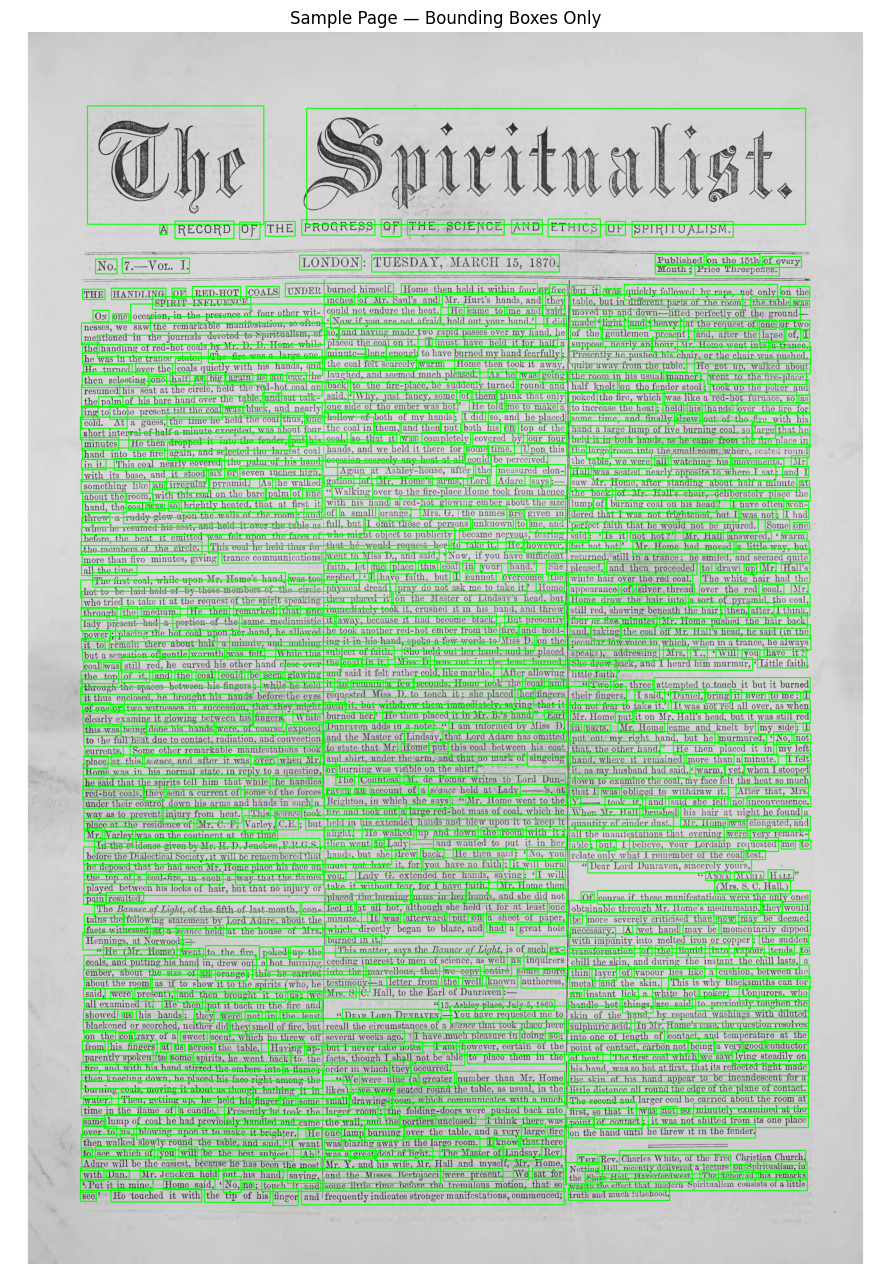

In [2]:
# visualisation of layout detection, with OpenCV pre-processing, as a comparison to the other OCR tools deployed during the fellowship

# import layout detection algorithm 

import cv2

# file configuration, again replace with your own file paths

sample_image_path = "/Users/joenockels/Spiritualist_Sample/0001.png"
output_image_path = "/Users/joenockels/Spiritualist_Sample/0001_boxes.png"

# initialise EasyOCR reader
reader = easyocr.Reader(['en'])

# read image
image = cv2.imread(sample_image_path)

# run OCR
results = reader.readtext(sample_image_path)

# draw ONLY bounding boxes (no text labels, as we are only concerned with processing not presentation)
for (bbox, text, prob) in results:
    top_left = tuple(map(int, bbox[0]))
    bottom_right = tuple(map(int, bbox[2]))
    
    # denote the boundaries as green rectangle for digital accessibility
    cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)

# save the image with bounding boxes, for future reference
cv2.imwrite(output_image_path, image)
print(f"Saved bounding-box image to: {output_image_path}")

# display the image inline, with a title for brief presentation
plt.figure(figsize=(12, 16))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Sample Page — Bounding Boxes Only")
plt.show()

<a href = '#section 2'><h4>OCR Processing</h4></a>

With our initial OCR confidence and visual tests conducted, we can begin to construct our OCR processing loop using EasyOCR. 

**Step 1** - We begin by importing the time package to track EasyOCR processing, a useful metric for directing NLS decision-making about changes in OCR licenses, as well as those enabling the sequential processing of local files. 

In [ ]:
import os
import time
import numpy as np

**Step 2** - We can then establish our folder structure, both for image imports and the continous OCR .txt file we hope to generate. As above, replace these with your own file paths, and denote the number of images for reference.

In [ ]:
image_folder = "/Users/joenockels/Spiritualist_Sample/"
output_text_file = "/Users/joenockels/Spiritualist_Sample/easyOCR.txt"
num_pages = 50  

**Step 3** - With the required packages imported and folder structure defined, we can now initialise our EasyOCR English language model.

In [ ]:
reader = easyocr.Reader(['en'])

**Step 4** - With our second visual preparation test in *Section 1* showing that OpenCV performs relatively accurately in word detection, but fails to recognise column structures, we can establish a function that forces OpenCV to default to three set column layouts. This follows the Pillow method, used in some of the other NLS Jupyter Notebooks in this series. We also include a method for converting each *Spiritualist* page into the required binary to detect page contours accordingly, to increase OCR accuracy. Though we used R Studio and Image Magick to perform cropping operations and thresholding, this function also filters any additional noise present in the image. 

In [ ]:
def detect_columns(image_path, expected_columns=3):
    """Return bounding boxes for detected newspaper columns."""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # threshold → binary
    thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)[1]

    # dilate to group text vertically
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 5))
    dilated = cv2.dilate(thresh, kernel, iterations=2)

    # find contours → potential column regions
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # convert contours to bounding boxes
    boxes = [cv2.boundingRect(c) for c in contours]

    # filter out small noise
    boxes = [b for b in boxes if b[2] > 200 and b[3] > 200]

    # sort by x-coordinate (left → right)
    boxes = sorted(boxes, key=lambda b: b[0])

    # if extra contours detected, merge to the closest "expected_columns" groups
    if len(boxes) > expected_columns:
        # Simple heuristic: choose the widest boxes
        boxes = sorted(boxes, key=lambda b: b[2], reverse=True)[:expected_columns]
        boxes = sorted(boxes, key=lambda b: b[0])  # reorder left → right

    return boxes, img

**Step 5** - With our layout function constructed, based on our preparation configurations, we can now begin our timer and start our OCR processing loop. The following code also includes printed messages for each page processed. This is to enable the user to track their EasyOCR operation as well as error handling, if a certain page is hard to parse.

In [3]:
# start timer
start_time = time.time()

with open(output_text_file, "w", encoding="utf-8") as f_out:
    for i in range(1, num_pages + 1):
        image_path = os.path.join(image_folder, f"{i:04}.png")
        print(f"Processing page {i}...")

        # detect columns and crop 
        column_boxes, base_img = detect_columns(image_path)

        page_text = []

        for idx, (x, y, w, h) in enumerate(column_boxes):
            column_crop = base_img[y:y+h, x:x+w]

            # Run OCR on the cropped column
            results = reader.readtext(column_crop)
            column_text = " ".join([t[1] for t in results])

            page_text.append(column_text)

        # combine columns in proper reading order
        full_page_text = "\n\n".join(page_text)

        f_out.write(full_page_text)
        f_out.write(f"\n\n--- Page {i} ---\n\n")

# timer
end_time = time.time()
elapsed = end_time - start_time

# print messages as a guide for processing progress, as well as denoting the time per page, as a useful metric for assessing OCR capability at-scale

print(f"OCR complete! All text saved to {output_text_file}")
print(f"Total processing time: {elapsed:.2f}s")
print(f"Average time per page: {elapsed / num_pages:.2f}s")

Processing page 1...
Processing page 2...
Processing page 3...
Processing page 4...
Processing page 5...
Processing page 6...
Processing page 7...
Processing page 8...
Processing page 9...
Processing page 10...
Processing page 11...
Processing page 12...
Processing page 13...
Processing page 14...
Processing page 15...
Processing page 16...
Processing page 17...
Processing page 18...
Processing page 19...
Processing page 20...
Processing page 21...
Processing page 22...
Processing page 23...
Processing page 24...
Processing page 25...
Processing page 26...
Processing page 27...
Processing page 28...
Processing page 29...
Processing page 30...
Processing page 31...
Processing page 32...
Processing page 33...
Processing page 34...
Processing page 35...
Processing page 36...
Processing page 37...
Processing page 38...
Processing page 39...
Processing page 40...
Processing page 41...
Processing page 42...
Processing page 43...
Processing page 44...
Processing page 45...
Processing page 46.

<a href = '#section 3'><h4>Post-Processing</h4></a>

With ALTO XML (https://www.loc.gov/standards/alto/) needed for interative *Spiritualist* image hosting, the following code re-runs the EasyOCR loop. This is kept as a separated cell for users who only need a continuous .txt export and are less concerned with browsable / zoomable image hosting. Nonetheless, this is essential for the DHI's web dashboard of OCR transcriptions, corresponded to each *Spiritualist* image, or your own IIIF viewer.

In [8]:
# import lxml for the ALTO XML build

from lxml import etree

# as with the previous processing loop, establish your file configuration, with your own file paths and establish a directory 

image_folder = "/Users/joenockels/Spiritualist_Sample/"
output_folder = "/Users/joenockels/Spiritualist_Sample/alto/"
num_pages = 50
os.makedirs(output_folder, exist_ok=True)

# load the OCR engine

reader = easyocr.Reader(['en'])

# here is our detect column function again, to parse each newspaper image correctly and retain reading order, alongside the pre-processing operations to minimise noise

def detect_columns(image_path, expected_columns=3):
    """
    Returns bounding boxes for detected columns as (x, y, w, h)
    """
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Threshold → isolate text blocks
    thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)[1]

    # Thicken vertical structures to form columns
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 5))
    dilated = cv2.dilate(thresh, kernel, iterations=2)

    # Find column contours
    contours, _ = cv2.findContours(
        dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # Convert contours to bounding boxes
    boxes = [cv2.boundingRect(c) for c in contours]

    # Sort left → right
    boxes = sorted(boxes, key=lambda b: b[0])

    # If more boxes than expected, take the largest ones
    if len(boxes) > expected_columns:
        boxes = sorted(boxes, key=lambda b: b[2] * b[3], reverse=True)[:expected_columns]
        boxes = sorted(boxes, key=lambda b: b[0])

    return boxes


# ------------------ ALTO XML GENERATOR ------------------
def generate_alto_xml(page_num, ocr_results, image_shape):
    """
    Builds standard ALTO XML (v4).
    ocr_results = [(box, text, conf), ...]
    """
    NS = "http://www.loc.gov/standards/alto/ns-v4#"
    root = etree.Element("alto", xmlns=NS)

    layout = etree.SubElement(root, "Layout")
    page = etree.SubElement(
        layout,
        "Page",
        ID=f"page_{page_num}",
        PHYSICAL_IMG_NR=str(page_num),
        WIDTH=str(image_shape[1]),
        HEIGHT=str(image_shape[0])
    )

    print_space = etree.SubElement(page, "PrintSpace")

    for box, text, conf in ocr_results:
        xs = [p[0] for p in box]
        ys = [p[1] for p in box]
        x = min(xs)
        y = min(ys)
        w = max(xs) - x
        h = max(ys) - y

        etree.SubElement(
            print_space,
            "String",
            CONTENT=text,
            HPOS=str(int(x)),
            VPOS=str(int(y)),
            WIDTH=str(int(w)),
            HEIGHT=str(int(h)),
            WC=str(conf / 100.0)
        )

    return etree.ElementTree(root)


# Processing loop per-page
for i in range(1, num_pages + 1):
    image_path = os.path.join(image_folder, f"{i:04}.png")

    if not os.path.exists(image_path):
        print(f"Missing image: {image_path}")
        continue

    print(f"Processing page {i}...")
    img = cv2.imread(image_path)

    # Detect columns
    columns = detect_columns(image_path)

    ocr_results = []

    # OCR each column independently
    for (x, y, w, h) in columns:
        column_img = img[y:y+h, x:x+w]

        results = reader.readtext(column_img)

        # Shift results back to full-page coordinates
        for box, text, conf in results:
            shifted_box = [[p[0] + x, p[1] + y] for p in box]
            ocr_results.append((shifted_box, text, conf))

    # Generate ALTO XML
    alto_xml = generate_alto_xml(i, ocr_results, img.shape)

    # Save ALTO file
    out_file = os.path.join(output_folder, f"{i}.xml")**Summary** - This code has provided a pipeline for uploading and OCRing png. images of *The Spiritualist*, a 19th century newspaper taken from the National Library of Scotland's Data Foundry, using Tesseract OCR. We also provide an ALTO XML generator for IIIF compliant transcription outputs. The exported plain .txt export will be used to generate CERs externally from this notebook and offer a comparison to the other OCR engines tested as part of this notebook series.

For any further guidance, comments or questions - contact Dr Joe Nockels at j.nockels@sheffield.ac.uk.
    alto_xml.write(out_file, pretty_print=True, encoding="utf-8", xml_declaration=True)

    print(f"Saved: {out_file}")

print("\n✔ All pages processed.")

Processing page 1...
Saved: /Users/joenockels/Spiritualist_Sample/alto/1.xml
Processing page 2...
Saved: /Users/joenockels/Spiritualist_Sample/alto/2.xml
Processing page 3...
Saved: /Users/joenockels/Spiritualist_Sample/alto/3.xml
Processing page 4...
Saved: /Users/joenockels/Spiritualist_Sample/alto/4.xml
Processing page 5...
Saved: /Users/joenockels/Spiritualist_Sample/alto/5.xml
Processing page 6...
Saved: /Users/joenockels/Spiritualist_Sample/alto/6.xml
Processing page 7...
Saved: /Users/joenockels/Spiritualist_Sample/alto/7.xml
Processing page 8...
Saved: /Users/joenockels/Spiritualist_Sample/alto/8.xml
Processing page 9...
Saved: /Users/joenockels/Spiritualist_Sample/alto/9.xml
Processing page 10...
Saved: /Users/joenockels/Spiritualist_Sample/alto/10.xml
Processing page 11...
Saved: /Users/joenockels/Spiritualist_Sample/alto/11.xml
Processing page 12...
Saved: /Users/joenockels/Spiritualist_Sample/alto/12.xml
Processing page 13...
Saved: /Users/joenockels/Spiritualist_Sample/alt

**Summary** - This code has provided a pipeline for uploading and OCRing png. images of *The Spiritualist*, a 19th century newspaper taken from the National Library of Scotland's Data Foundry, using EasyOCR.

We also provide an ALTO XML generator for IIIF compliant transcription outputs. The exported plain .txt export will be used to generate CERs externally from this notebook and offer a comparison to the other OCR engines tested as part of this notebook series.

For any further guidance, comments or questions - contact Dr Joe Nockels at j.nockels@sheffield.ac.uk.